In [66]:
import numpy as np
import pandas as pd

#from sklearn.datasets import load_breast_cancer
diabetes_df = pd.read_csv('diabetes.csv', sep = ',', header = 0, engine = 'python')

In [67]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [68]:
diabetes_df.shape

(768, 9)

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [70]:
diabetes_scaled = scaler.fit_transform(diabetes_df.drop(['Outcome'], axis = 1, inplace = False))

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [72]:
Y = diabetes_df['Outcome']
X = diabetes_scaled

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

In [74]:
lr_diabetes = LogisticRegression()

In [75]:
lr_diabetes.fit(X_train, Y_train)

LogisticRegression()

In [76]:
Y_predict = lr_diabetes.predict(X_test)

In [77]:
print(Y_predict)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0
 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 0 0 0]


In [78]:
# 상위 5개 예측 분류
print(lr_diabetes.predict(X_test[:5]))

[1 0 0 1 0]


In [79]:
# 상위 5개 예측 확률
print(lr_diabetes.predict_proba(X_test[:5]))

[[0.04507133 0.95492867]
 [0.84018944 0.15981056]
 [0.91459762 0.08540238]
 [0.35905824 0.64094176]
 [0.88633301 0.11366699]]


In [80]:
print('Y 절편 값 : ', lr_diabetes.intercept_)
print('회귀 계수 값 : ', np.round(lr_diabetes.coef_, 1))

Y 절편 값 :  [-0.85075352]
회귀 계수 값 :  [[ 0.3  1.1 -0.2  0.1 -0.1  0.7  0.3  0.3]]


In [81]:
# z 값 출력
decisions = lr_diabetes.decision_function(X_test[:5])

In [82]:
print(decisions)

[ 3.0533904  -1.65963825 -2.37111026  0.57945397 -2.05381966]


In [83]:
from scipy.special import expit

In [84]:
print(expit(decisions))

[0.95492867 0.15981056 0.08540238 0.64094176 0.11366699]


In [85]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [86]:
#오차 행렬
confusion_matrix(Y_test, Y_predict)

array([[141,  16],
       [ 35,  39]])

**TN(00) = 157 / FP(01) = 0 / FN(10) = 0 / TP(11) = 74**

In [87]:
accuracy = accuracy_score(Y_test, Y_predict)
precision = precision_score(Y_test, Y_predict) # 정밀도 TP / FP + TP
recall = recall_score(Y_test, Y_predict) # 재현율 TP / FN + TP
f1 = f1_score(Y_test, Y_predict)
roc_auc = roc_auc_score(Y_test, Y_predict)

In [88]:
print('정확도 : {0:.3f}, 정밀도 : {1:.3f}, 재현율 : {2:.3f}, F! : {3:.3f}'.format(accuracy, precision, recall, f1))

정확도 : 0.779, 정밀도 : 0.709, 재현율 : 0.527, F! : 0.605


In [89]:
print('ROC_AUC : {0:.3f}'.format(roc_auc))

ROC_AUC : 0.713


In [90]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [91]:
### ROC curve
### roc curve 패키지로 fpr, tpr 뽑기
model_fpr, model_tpr, threshold1 = roc_curve(Y_test, Y_predict)

In [92]:
### 랜덤하게 했을때는 fpr, tpr 모두 0.5, 0.5로 나온다. 
random_fpr, random_tpr, threshold2 = roc_curve(Y_test, [0 for i in range(len(X_test))]) 

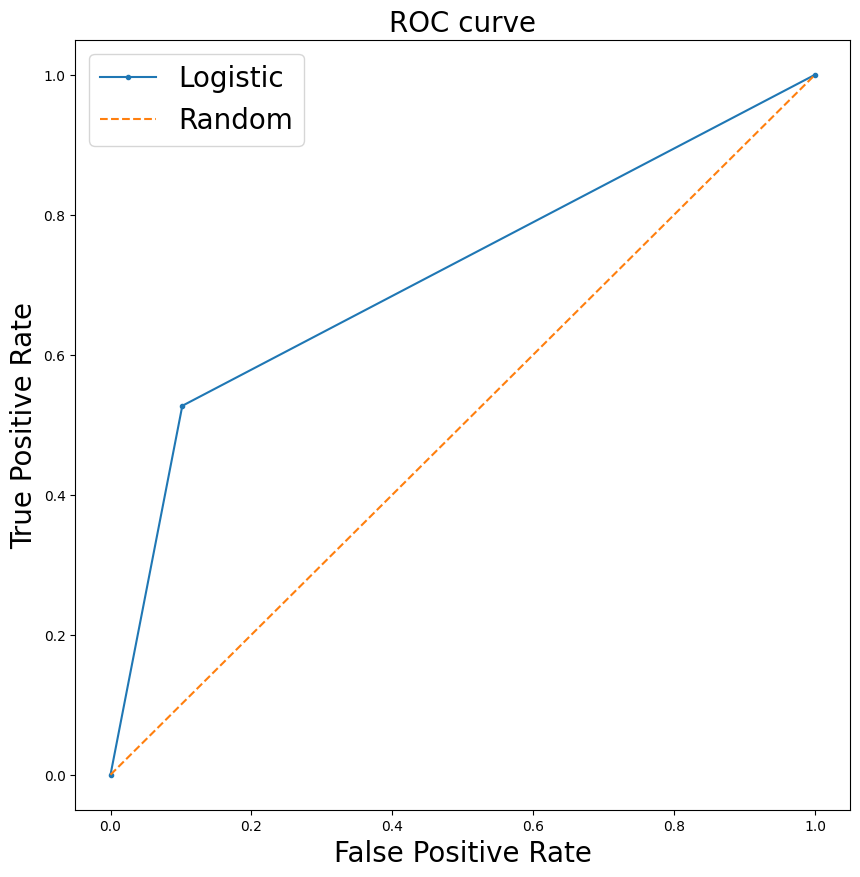

In [93]:
plt.figure(figsize = (10,10))
plt.plot(model_fpr, model_tpr, marker = '.', label = "Logistic")
plt.plot(random_fpr, random_tpr, linestyle = '--', label = "Random")

plt.xlabel("False Positive Rate", size = 20)
plt.ylabel("True Positive Rate", size = 20)

plt.legend(fontsize = 20)

plt.title("ROC curve", size = 20)
plt.show()
